In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List

In [2]:
class AgentState(TypedDict):
    number1 : int
    number2 : int
    number3 : int
    number4 : int
    operation : str
    operation2: str
    final_number: int
    is_first_operation : bool

In [3]:
def adder(state: AgentState) -> AgentState:
    """ Adds two numbers """
    if state["is_first_operation"]:
        state['final_number'] = state['number1'] + state['number2']
        state["is_first_operation"] = False
    else:
        state['final_number'] += state['number3'] + state['number4']
    return state

def substractor(state: AgentState) -> AgentState:
    """ Substracts two numbers """
    if state["is_first_operation"]:
        state['final_number'] = state['number1'] - state['number2']
        state["is_first_operation"] = False
    else:
        state['final_number'] -= (state['number3'] + state['number4'])
    return state

def decide_next_node(state: AgentState) -> AgentState:
    """ This node will select the next node of the graph"""
    operation = state['operation']
    # Returning the correct edge
    if operation == "+":
        return "addition_operation"
    elif operation == "-":
        return "substraction_operation"

def decide_next_node2(state: AgentState) -> AgentState:
    """ This node will select the next node of the graph"""
    operation = state['operation2']
    # Returning the correct edge
    if operation == "+":
        return "addition_operation2"
    elif operation == "-":
        return "substraction_operation2"

In [4]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("substract_node", substractor)
graph.add_node("router", lambda state: state)

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "addition_operation" : "add_node",
        "substraction_operation": "substract_node"
    }
)

graph.add_edge("add_node", "router2")
graph.add_edge("substract_node", "router2")

graph.add_node("add_node2", adder)
graph.add_node("substract_node2", substractor)

graph.add_node("router2", lambda state: state)
graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {
        "addition_operation2" : "add_node2",
        "substraction_operation2": "substract_node2"
    }
)

graph.add_edge("add_node2", END)
graph.add_edge("substract_node2", END)

app = graph.compile()

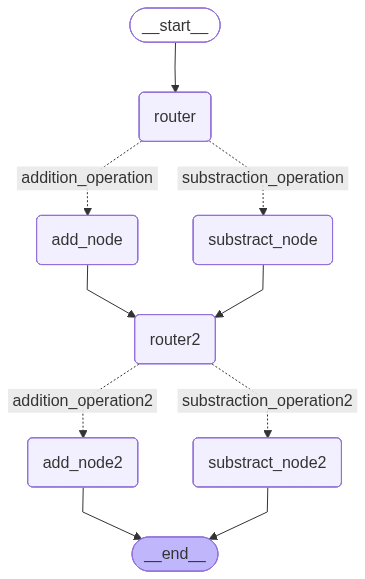

In [5]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [6]:
initial_state_1 = AgentState(
    number1=10, 
    number2=20, 
    operation="-",
    number3=30,
    number4=40,
    operation2="+",
    final_number=0,
    is_first_operation=True
)
print(app.invoke(initial_state_1))

{'number1': 10, 'number2': 20, 'number3': 30, 'number4': 40, 'operation': '-', 'operation2': '+', 'final_number': 60, 'is_first_operation': False}


In [7]:
initial_state_2 = AgentState(
    number1=20, 
    number2=20, 
    operation="+",
    number3=10,
    number4=15,
    operation2="-",
    final_number=0,
    is_first_operation=True
)
print(app.invoke(initial_state_2))

{'number1': 20, 'number2': 20, 'number3': 10, 'number4': 15, 'operation': '+', 'operation2': '-', 'final_number': 15, 'is_first_operation': False}
